# 20260721 pairwise interaction — read-mapping validation

**Question.** For every well with more than 5 demultiplexed reads, do the reads actually
match the strain(s) the plate layout (`setup/strain_layout_20260721_plate1_2_swapped.csv`)
says should be there?

**Approach** (following `check_reads.ipynb`'s conventions — edlib normalized edit distance,
`demux/unflipped` as the read source, ONT full-length 16S reads):

1. **Constrained mapping** (edlib) — for every read, compute the normalized edit distance to
   *only* the reference sequence(s) of that well's expected strain(s) (`strain1`/`strain2`).
   This directly answers "does this read look like what's supposed to be here."
2. **Unconstrained mapping** (minimap2) — map every read against *all* 87 strains in a
   reference db. This is the complement: when a read doesn't look like what's expected, this
   says what it actually does look like — the signature of cross-well contamination or a
   mislabeled well.

Three candidate reference databases were named in the analysis plan: `corroborated_db`
(external, from past experiments), and this experiment's own `merged_consensus_20260721` /
`merged_consensus_mono_priority_20260721` (built by `analysis/per_strain_consensus.ipynb`).
**Step 2 below finds that `corroborated_db`'s strain-name labels are only reliable for a
minority of strains in this experiment** — an important, non-obvious result that determines
which database is used as ground truth for everything downstream.

All heavy lifting lives in `scripts/s01`–`s06`, written as plain functions so they can be
unit-tested, re-run from the command line, *and* imported here. This notebook just calls
them in order, and reports + visualizes what came out.


In [1]:
import sys
from pathlib import Path

NB_DIR = Path.cwd()
SCRIPTS_DIR = NB_DIR / "scripts"
sys.path.insert(0, str(SCRIPTS_DIR))

import pandas as pd
from IPython.display import Image, display, Markdown

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

from common import OUT_DIR, FIG_DIR, REFERENCE_DBS, MIN_READS

def show(png_name, width=880):
    display(Image(filename=str(FIG_DIR / png_name), width=width))

print(f"outputs -> {OUT_DIR}")
print(f"figures -> {FIG_DIR}")
print(f"reference dbs:")
for name, path in REFERENCE_DBS.items():
    print(f"  {name:32s} {path}")


outputs -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/mapping_validation/outputs
figures -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/mapping_validation/outputs/figures
reference dbs:
  corroborated_db                  /home/rl/scripts/karl/merge_consensus_sequences/collapse_naive_updated3_15diff/corroborated_db_filtered_min5.fasta
  merged_consensus                 /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/consensus/merged_consensus_20260721.fasta
  merged_consensus_mono_priority   /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/consensus/merged_consensus_mono_priority_20260721.fasta


## Step 1 — which wells qualify?

Every well in the layout is resolved to its demultiplexed fastq (`demux/unflipped/`, the
final/complete demux run — 9120/9120 wells present) and read-counted. We keep wells with
**more than 5 reads**, per the analysis plan.


In [2]:
from s01_gather_samples import gather_samples

samples = gather_samples()


layout wells               : 9120
  missing fastq files      : 0
wells with > 5 reads      : 2644
  well_type breakdown      : {'pair': 2618, 'mono': 26}
  total reads in cohort    : 113197
saved -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/mapping_validation/outputs/01_samples_gt5reads.csv


In [3]:
display(samples.head())
print()
print("well_type counts:", samples["well_type"].value_counts().to_dict())
print("mono wells with >5 reads:", (samples.well_type == "mono").sum())


,sample_id,dest_plate,dest_row,dest_col,dest_well,well_type,strain1,strain2,n_reads,path
0,Plate01_B11,1,B,11,B11,pair,F7,D13,21,/home/rl/scripts/karl/pairwise_interaction_exp...
1,Plate01_B13,1,B,13,B13,pair,L24,K2,65,/home/rl/scripts/karl/pairwise_interaction_exp...
2,Plate01_B14,1,B,14,B14,pair,J18,O17,15,/home/rl/scripts/karl/pairwise_interaction_exp...
3,Plate01_B15,1,B,15,B15,pair,C19,D13,34,/home/rl/scripts/karl/pairwise_interaction_exp...
4,Plate01_B16,1,B,16,B16,pair,I19,N13,7,/home/rl/scripts/karl/pairwise_interaction_exp...



well_type counts: {'pair': 2618, 'mono': 26}
mono wells with >5 reads: 26


## Step 2 — reference databases: coverage, and a critical reliability check

Strain names in this project (`A11`, `D13`, `G5`, ...) are short plate-well-style labels.
They get reused across many unrelated plate layouts over the years. `corroborated_db` is
pooled from many past experiments — so a name match there is **not automatically an identity
match**. We check this directly: for every strain, compare `corroborated_db`'s sequence to
`merged_consensus_mono_priority`'s sequence for that same name (the latter is built entirely
from *this* experiment's own reads, so its labels are self-consistent by construction). A
large distance between the two means the `corroborated_db` entry is almost certainly a
different organism that happens to share the name.


In [4]:
from s02_prepare_references import prepare_references

dbs, coverage, cross_check = prepare_references()


strains in layout: 87
  corroborated_db                  /home/rl/scripts/karl/merge_consensus_sequences/collapse_naive_updated3_15diff/corroborated_db_filtered_min5.fasta
    covers 87/87 strains
  merged_consensus                 /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/consensus/merged_consensus_20260721.fasta
    covers 86/87 strains
  merged_consensus_mono_priority   /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/consensus/merged_consensus_mono_priority_20260721.fasta
    covers 86/87 strains
saved -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/mapping_validation/outputs/02_reference_coverage.csv

corroborated_db identity cross-check (86 strains comparable):
  21/86 strain names agree with this experiment's own consensus (< 0.1 normalized edit distance)
  65/86 strain names in corroborated_db do NOT match this experiment's sequence for that name -- likely coincidental reuse of a plate-well-style

**21/86 strain names in `corroborated_db` agree with this experiment's own consensus.** The other 65 are treated as name collisions, not the same organism. This is why `merged_consensus_mono_priority` -- built entirely from this experiment's own reads -- is used as the **primary** reference for everything below; `corroborated_db` is kept only as a secondary, informational check.

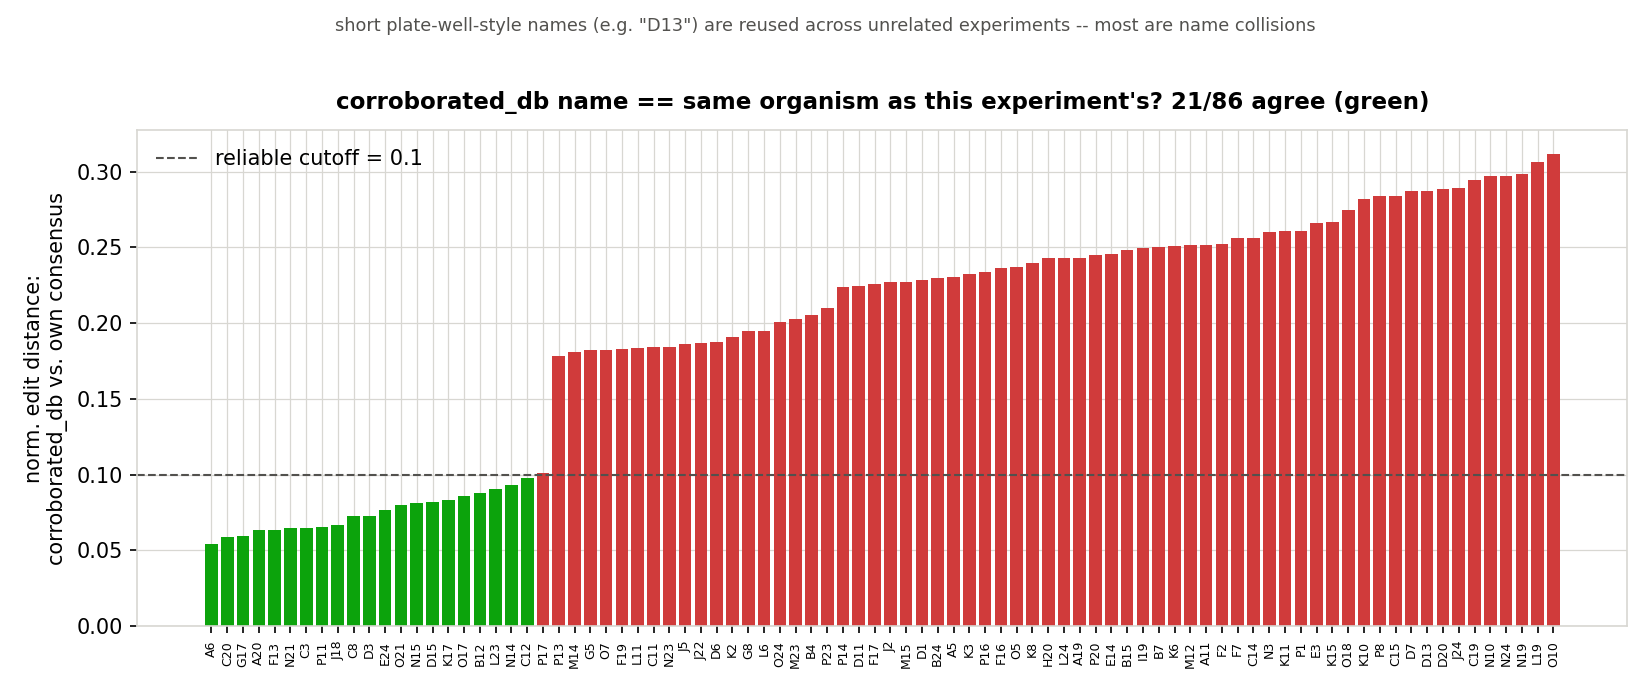

In [5]:
n_reliable = int(cross_check["reliable"].sum())
display(Markdown(
    f"**{n_reliable}/{len(cross_check)} strain names in `corroborated_db` agree with this "
    f"experiment's own consensus.** The other {len(cross_check) - n_reliable} are treated as "
    "name collisions, not the same organism. This is why `merged_consensus_mono_priority` -- "
    "built entirely from this experiment's own reads -- is used as the **primary** reference "
    "for everything below; `corroborated_db` is kept only as a secondary, informational check."
))
show("00_reference_reliability_check.png")


## Step 3 — constrained mapping: does each read match its expected strain(s)?

For every read in every qualifying well, edlib computes the normalized edit distance to each
candidate reference (`strain1`, and `strain2` if it's a pair well) in each of the three
databases. Runtime: ~113k reads × up to 2 candidates × 3 dbs ≈ 40s.


In [6]:
from s03_constrained_edlib_mapping import run_all as run_edlib_all

edlib_results = run_edlib_all(samples)


[corroborated_db] 2644/2644 wells had a reference for >=1 expected strain (0 skipped, no reference available); 113197 reads classified -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/mapping_validation/outputs/03_edlib_read_assignments_corroborated_db.csv.gz


[merged_consensus] 2644/2644 wells had a reference for >=1 expected strain (0 skipped, no reference available); 113197 reads classified -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/mapping_validation/outputs/03_edlib_read_assignments_merged_consensus.csv.gz


[merged_consensus_mono_priority] 2644/2644 wells had a reference for >=1 expected strain (0 skipped, no reference available); 113197 reads classified -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/mapping_validation/outputs/03_edlib_read_assignments_merged_consensus_mono_priority.csv.gz


## Step 4 — unconstrained cross-check: minimap2 against all 87 strains

Every read is also mapped (minimap2, `map-ont` preset) against the *complete* reference db —
not just the 1-2 expected strains. This is what lets us say not just "this read doesn't match
what's expected" but "this read actually looks like strain X" — the contamination signature.
Runtime: ~113k reads × 3 dbs, a few minutes.


In [7]:
from s04_minimap2_contamination_scan import run_all as run_minimap2_all

minimap2_results = run_minimap2_all(samples)


[corroborated_db] 113205/113205 reads mapped (100.0%); 1480/113205 best-hit an expected strain (1.3%) -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/mapping_validation/outputs/04_minimap2_read_besthit_corroborated_db.csv


[merged_consensus] 113205/113205 reads mapped (100.0%); 80078/113205 best-hit an expected strain (70.7%) -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/mapping_validation/outputs/04_minimap2_read_besthit_merged_consensus.csv


[merged_consensus_mono_priority] 113205/113205 reads mapped (100.0%); 77889/113205 best-hit an expected strain (68.8%) -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/mapping_validation/outputs/04_minimap2_read_besthit_merged_consensus_mono_priority.csv


## Step 5 — combine, QC-call every well, flag contamination

A **confident-match threshold** for "is this read really the reference strain, or just
noise" is learned once (data-driven valley in the pooled edlib distance distribution, same
idea as `check_reads.ipynb`) from the primary db only, then applied everywhere — fitting it
per-db would let `corroborated_db`'s name-collision noise drag its own threshold down and
mask real matches (this was caught and fixed during development; see script docstring).

A strain then "counts" as present in a well if it has enough confident reads
(`max(3, 10% of reads)`, the same rule as `check_reads.ipynb` / `per_strain_consensus.ipynb`).
Each well gets a `qc_status`:

| status | meaning |
|---|---|
| `pair_both_confirmed` / `mono_confirmed` | reads support what the layout says |
| `pair_single_dominant` / `mono_low_confidence` | only one strain (or too few reads) confirmed |
| `pair_neither_confirmed` | **neither** expected strain found — top QC concern |

Separately, `qc_contaminated` flags wells where minimap2's genome-wide best hit is dominated
(≥20%, ≥3 reads) by a strain that isn't expected — each is further annotated with how close
that "contaminant" strain's own reference is to the well's expected strain(s), since some of
the biggest offenders turn out to be **reference near-twins** that 16S genuinely cannot
resolve (see below), not real contamination.


In [8]:
from s05_combine_and_flag import combine_and_flag, PRIMARY_DB, REFERENCE_TWIN_THRESHOLD

summary = combine_and_flag()


confident-match threshold (learned from merged_consensus_mono_priority, applied to all dbs): 0.128


combined summary: 2644 wells -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/mapping_validation/outputs/05_combined_sample_summary.csv

qc_status counts:
qc_status
pair_both_confirmed       1350
pair_single_dominant      1232
pair_neither_confirmed      36
mono_confirmed              26

contamination-flagged wells: 735 -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/mapping_validation/outputs/05_contamination_candidates.csv
  of which 578 are reference near-twins (<0.05 dist to expected strain's own reference -- 16S can't discriminate these, likely not real contamination)
  157 involve a genuinely divergent unexpected strain -- higher-priority follow-up


In [9]:
qc_counts = summary.groupby(["well_type", "qc_status"]).size().rename("n_wells")
display(qc_counts.to_frame())


n_wells
well_type qc_status                      
mono      mono_confirmed               26
pair      pair_both_confirmed        1350
          pair_neither_confirmed       36
          pair_single_dominant       1232

In [10]:
contam = pd.read_csv(OUT_DIR / "05_contamination_candidates.csv")
n_twin = int(contam["likely_reference_twin"].sum())
display(Markdown(
    f"**{len(contam)} wells flagged as contaminated.** {n_twin} are reference near-twins "
    f"(<{REFERENCE_TWIN_THRESHOLD} normalized edit distance between the 'contaminant' and the "
    f"well's own expected strain -- 16S can't tell these apart, so this is very unlikely to be "
    f"real contamination). **{len(contam) - n_twin} involve a genuinely divergent unexpected "
    "strain and are the higher-priority follow-up list.**"
))

genuine = contam[~contam.likely_reference_twin].sort_values(
    f"mm2_{PRIMARY_DB}_top_other_frac", ascending=False
)
display(genuine.head(15))


**735 wells flagged as contaminated.** 578 are reference near-twins (<0.05 normalized edit distance between the 'contaminant' and the well's own expected strain -- 16S can't tell these apart, so this is very unlikely to be real contamination). **157 involve a genuinely divergent unexpected strain and are the higher-priority follow-up list.**

,sample_id,well_type,strain1,strain2,n_reads,mm2_merged_consensus_mono_priority_top_other_strain,mm2_merged_consensus_mono_priority_top_other_count,mm2_merged_consensus_mono_priority_top_other_frac,contaminant_ref_dist_to_expected,likely_reference_twin,qc_status
5,Plate08_H7,pair,F2,J2,45,K3,43,0.955556,0.159776,False,pair_neither_confirmed
6,Plate04_F11,pair,A20,J2,64,P20,60,0.937500,0.213080,False,pair_neither_confirmed
7,Plate06_H15,pair,N13,J2,16,O5,15,0.937500,0.225156,False,pair_neither_confirmed
8,Plate12_I16,pair,B15,O18,12,K10,11,0.916667,0.164681,False,pair_neither_confirmed
10,Plate16_B22,pair,F2,B12,19,K3,17,0.894737,0.162579,False,pair_neither_confirmed
12,Plate14_G19,pair,N24,N21,59,K3,52,0.881356,0.160477,False,pair_single_dominant
13,Plate04_I17,pair,F2,K17,8,K3,7,0.875000,0.161177,False,pair_neither_confirmed
17,Plate16_B12,pair,E24,N13,14,P1,12,0.857143,0.180731,False,pair_neither_confirmed
19,Plate04_F21,pair,N21,E24,110,P1,93,0.845455,0.180731,False,pair_neither_confirmed
28,Plate12_B17,pair,P20,O18,44,K10,36,0.818182,0.164681,False,pair_single_dominant


**A specific pattern worth flagging by name:** wells where `strain1`/`strain2` includes
`F2` repeatedly best-hit `K3` genome-wide (58 wells, across many different actual partners for
F2) at ~16% divergence from F2's own reference — too far to be a near-twin, but a suspiciously
consistent, one-directional pattern. Worth a look at how `F2`'s own consensus sequence was
built. (`K6`/`P17`, by contrast, *are* a genuine reference near-twin at 1.5% apart, and account
for a large share of the near-twin-filtered wells above.)


In [11]:
display(Markdown("**`pair_neither_confirmed`** — wells where the constrained mapping "
                  "found neither expected strain (top QC concern, 36 wells):"))
worst = summary[summary.qc_status == "pair_neither_confirmed"][
    ["sample_id", "well_type", "strain1", "strain2", "n_reads",
     f"mm2_{PRIMARY_DB}_top_other_strain", f"mm2_{PRIMARY_DB}_top_other_frac"]
].sort_values("n_reads", ascending=False)
display(worst.head(15))


**`pair_neither_confirmed`** — wells where the constrained mapping found neither expected strain (top QC concern, 36 wells):

,sample_id,well_type,strain1,strain2,n_reads,mm2_merged_consensus_mono_priority_top_other_strain,mm2_merged_consensus_mono_priority_top_other_frac
344,Plate04_F21,pair,N21,E24,110,P1,0.845455
2452,Plate20_F5,pair,F2,O18,81,K3,0.604938
889,Plate08_K16,pair,K17,O18,65,K10,0.692308
335,Plate04_F11,pair,A20,J2,64,P20,0.937500
1012,Plate10_C20,pair,F2,N13,53,K3,0.660377
1323,Plate12_F13,pair,A20,L24,52,P20,0.788462
1038,Plate10_E10,pair,F2,O18,48,K3,0.625000
1138,Plate10_J2,pair,K17,A20,47,P20,0.617021
890,Plate08_K17,pair,F2,N13,45,K3,0.622222
842,Plate08_H7,pair,F2,J2,45,K3,0.955556


## Step 6 — figures

In [12]:
from s06_make_figures import make_all_figures

make_all_figures()


saved 7 figures -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/mapping_validation/outputs/figures


**Constrained mapping quality** — how well do reads match the reference they were assigned to?

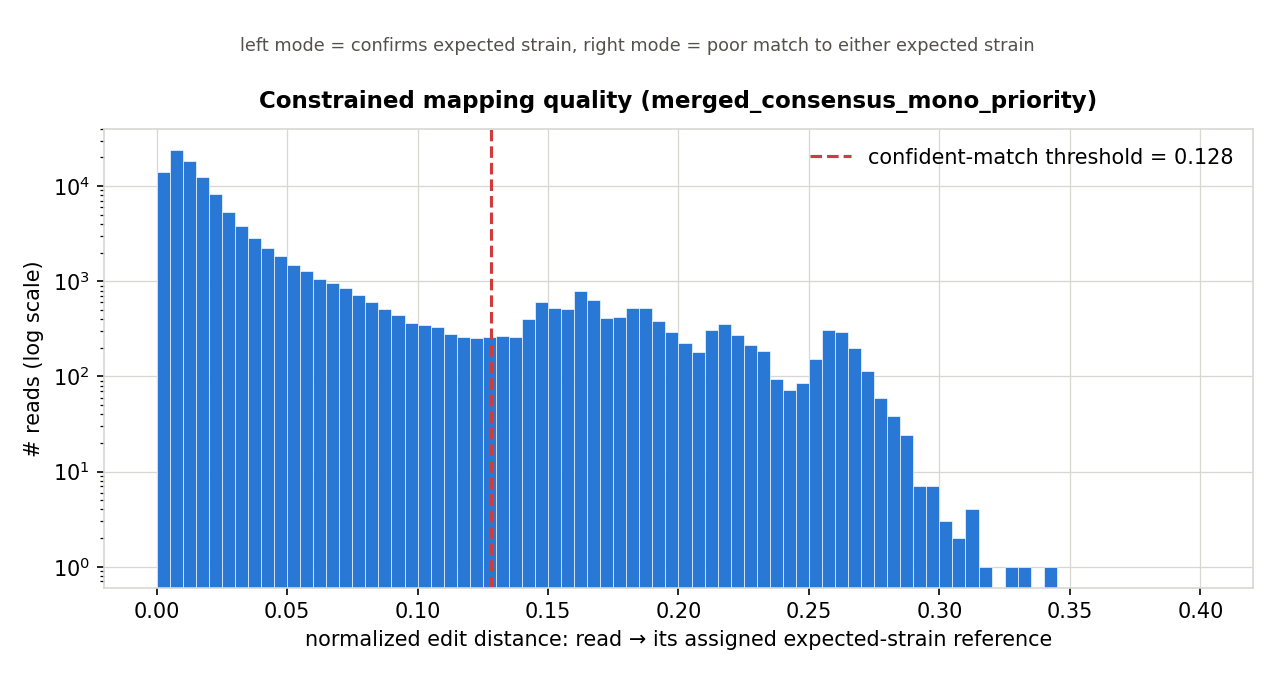

In [13]:
show("01_match_quality_histogram.png")

**QC call per well**, split by designed well type:

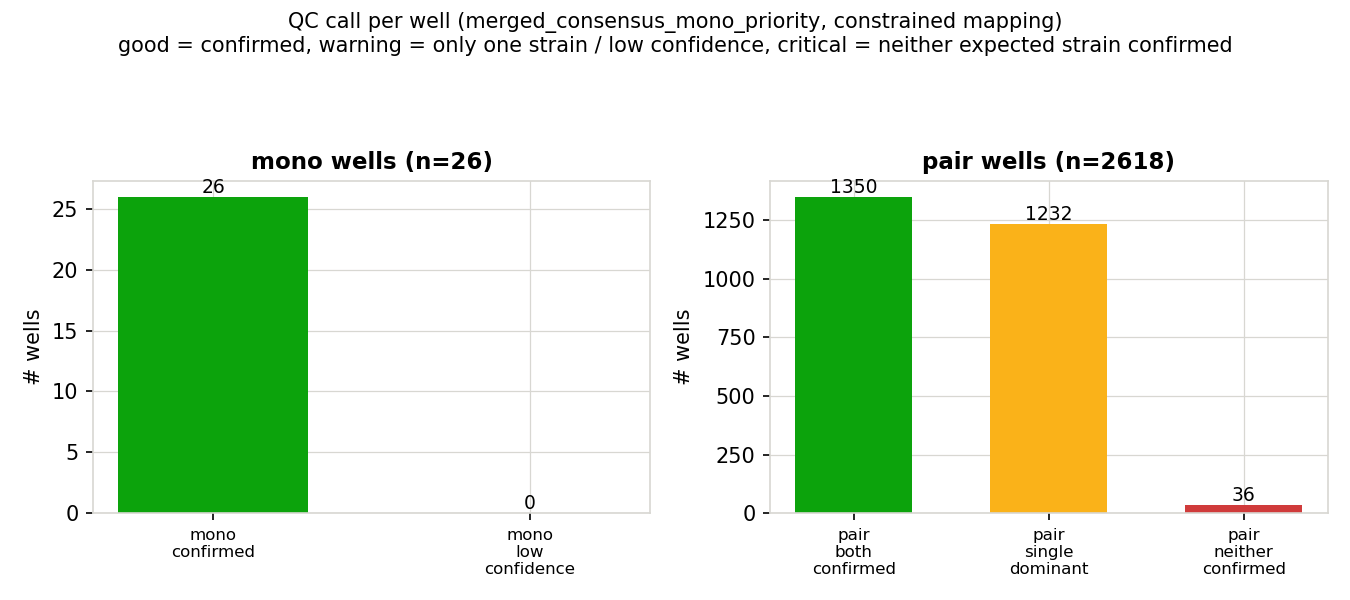

In [14]:
show("02_qc_status_by_well_type.png")

**Read purity** — fraction of confident reads supporting the dominant expected strain:

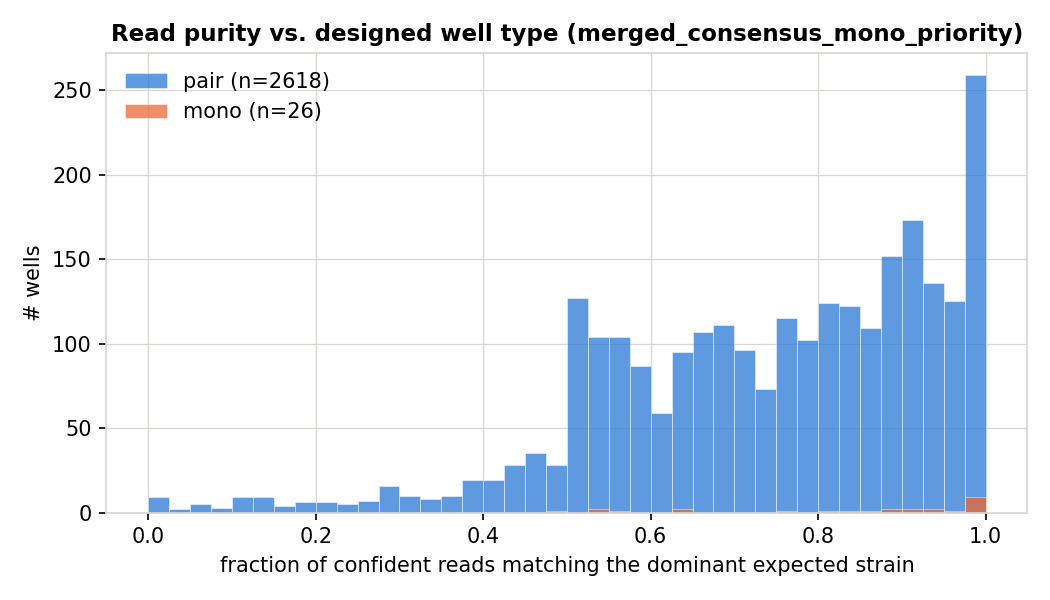

In [15]:
show("03_purity_histogram.png")

**Read depth vs. mapping confidence** — does a shallow well just look noisier, or genuinely worse?

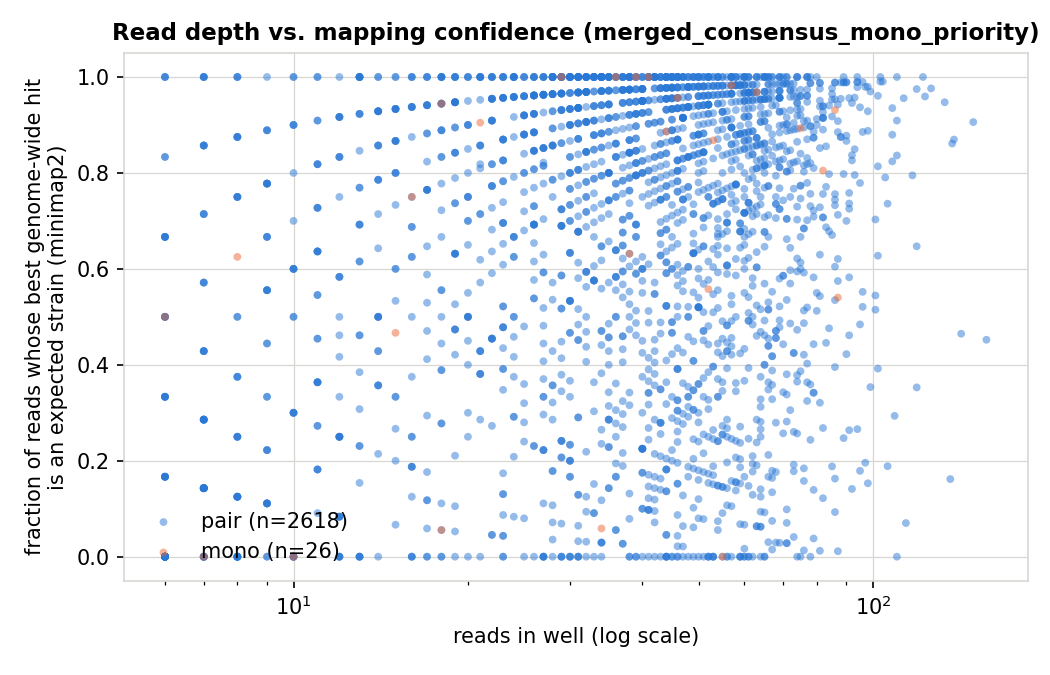

In [16]:
show("04_depth_vs_confidence.png")

**Independent vs. self-derived reference agreement**, restricted to name-reliable strains — sanity-checks that the primary db is trustworthy:

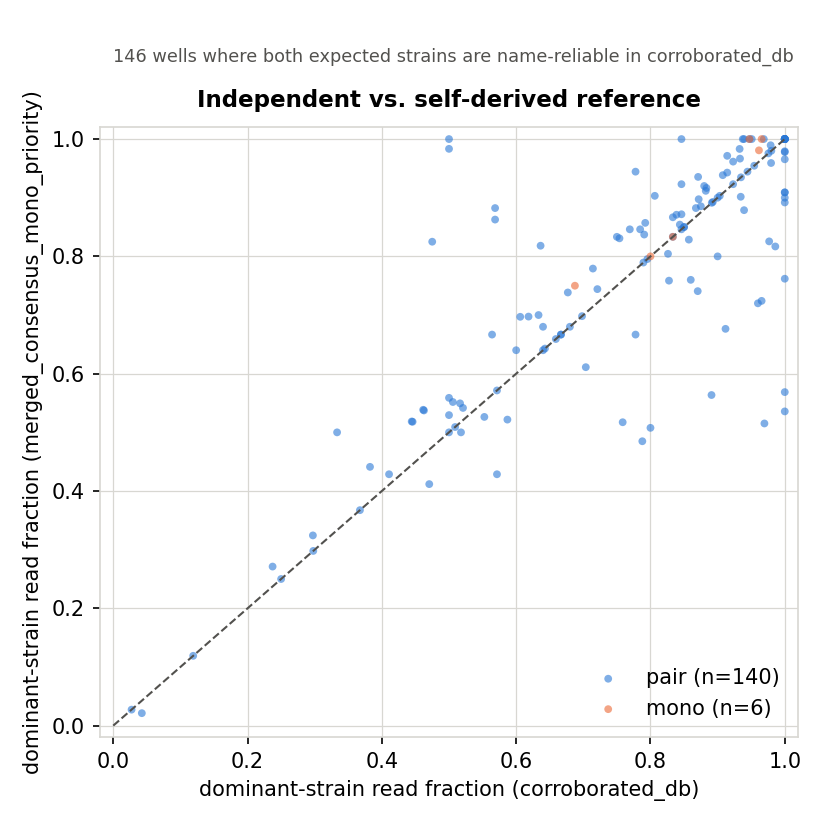

In [17]:
show("05_cross_db_agreement.png")

**Most frequent unexpected strains** (reference near-twins excluded) — candidates for real cross-well contamination:

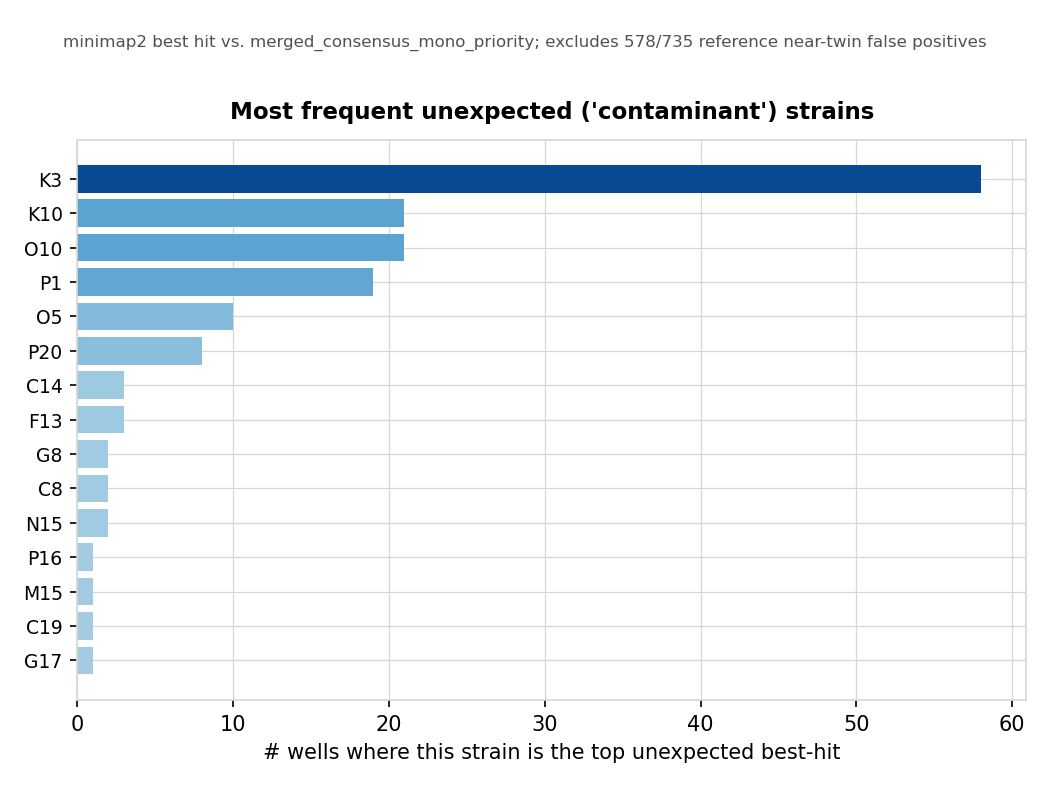

In [18]:
show("06_contamination_offenders.png")

## Key findings

1. **2,644 / 9,120 wells** (29%) have more than 5 reads (113,197 reads total); 26 are mono
   wells, 2,618 are pair wells.
2. **`corroborated_db` is not a safe ground truth for this experiment.** Only 21/86 strain
   names (24%) actually correspond to the same organism this experiment calls by that name —
   the rest are almost certainly coincidental reuse of a plate-well-style label from an
   unrelated experiment. `merged_consensus_mono_priority` (built from this experiment's own
   reads) is used as the primary reference instead; where corroborated_db names *are*
   reliable, the two agree well (figure 5).
3. **Mono wells validate cleanly**: 26/26 (100%) confirm their single expected strain —
   demultiplexing and library prep are working as intended for the unambiguous case.
4. **Pair wells**: 1,350/2,618 (52%) confirm both expected strains; 1,232 (47%) confirm only
   one (partner likely dropped out / was outcompeted, a known feature of these co-culture
   wells, not necessarily an error); 36 (1.4%) confirm neither — the highest-priority QC
   failures, listed above and in `outputs/05_combined_sample_summary.csv`.
5. **Contamination scan**: 735 wells flagged, but 578 are explained by strains whose own
   reference sequences are near-identical (e.g. `K6`/`P17`, 1.5% apart) — 16S genuinely can't
   discriminate these, so they are not evidence of real contamination. The remaining **157**
   are genuine candidates for follow-up, including a specific, repeated pattern where `F2`
   wells best-hit `K3` regardless of F2's actual partner (worth checking F2's own consensus
   build).

## Where everything lives

```
analysis/mapping_validation/
├── scripts/                              numbered, importable pipeline (s01-s06 + common.py)
├── outputs/
│   ├── 01_samples_gt5reads.csv           the >5-read cohort
│   ├── 02_reference_coverage.csv         strain x db sequence-length coverage
│   ├── 02_reference_cross_check.csv      corroborated_db identity reliability per strain
│   ├── 03_edlib_read_assignments_*.csv.gz   per-read constrained-mapping calls, per db
│   ├── 04_minimap2_*.paf / read_besthit_*.csv   per-read genome-wide best hit, per db
│   ├── 05_combined_sample_summary.csv    one row per well: every stat + qc_status
│   ├── 05_contamination_candidates.csv   flagged wells, twin-annotated
│   └── figures/                          the 7 PNGs shown above
└── <this notebook>
```

Re-running this notebook top to bottom regenerates every output from the raw fastqs.
